# Collecting simulated Duffing oscillator data

In [1]:
# --! include root folder into PYTHONPATH

import os
import sys

cur_dir = os.getcwd()

root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..', '..'))
sys.path.append(root_dir)

util_dir = os.path.abspath(os.path.join(cur_dir, '..', '..'))
sys.path.append(util_dir)

data_dir = f'{root_dir}/data/regimes/duffing'

# --! import Python libraries

import numpy as np
import matplotlib.pyplot as plt

import util_duffing
import util_data

### Instantiate Duffing environment

In [2]:
# --! define Duffing parameters --!

# --! define parameters of a nominal Duffing which is supposed to be stabilized by an LQR
duffing_alpha_nom = -1.0
duffing_delta_nom = 0.5

# --! define parameters of an anomalous Duffing which exhibits excursions from one well to the other
duffing_alpha = -110.0
duffing_beta = 140.0
duffing_gamma = 70.0
duffing_delta = duffing_delta_nom

In [3]:
# --! make a base policy --!

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 10.0 * np.eye(action_ndim)

# --! we aim to capture the Duffing in well (1,0)
setpoint = [1.0, 0.0]
dt = 1e-2

base_policy, _ = util_duffing.make_base_policy(
    duffing_alpha_nom, duffing_delta_nom,
    q=state_cost, r=action_cost,
    dt=dt,
    setpoint=setpoint, adapted=False)

In [4]:
# --! make a Duffing oscillator --!

reward_fn = util_duffing.reward(state_cost, action_cost, setpoint)

env = util_duffing.environment(
    reward_fn,
    alpha=duffing_alpha, beta=duffing_beta, gamma=duffing_gamma, delta=duffing_delta,
    dt_control=dt)


In [5]:
# --! define helper functions --!

def run_sim(env, base_policy, param_alpha, param_beta, sim_nsample):

    ss = np.zeros((sim_nsample, state_ndim))

    # --! reset environment
    env_ic = [0.0, 0.0]
    s = env.reset(env_ic)

    # --! update duffing parameters
    env.alpha = param_alpha
    env.beta = param_beta

    for i in range(sim_nsample):
        a = base_policy(s)
        ss[i] = s

        s, _, _ = env.step(np.squeeze(a))

    return ss

def plot_result(s, sim_nsample, dt):

    t = np.arange(sim_nsample) * dt

    plt.figure(figsize=(10, 3))

    plt.subplot(1,2,1)
    plt.plot(t, s[:, 0])
    plt.xlabel('Time (s)')
    plt.ylabel('Position')

    plt.subplot(1,2,2)
    plt.plot(t, s[:, 1])
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity')

    plt.tight_layout()
    plt.show()


### Run simulation

In [6]:
back_nsample = 64
sim_nsample = 20 * back_nsample

env_params = [
    (-110.0, 140.0),
    (-100.0, 130.0),
    (-110.0, 110.0),
    (-90.0, 100.0),
    (-80.0, 80.0),
    (-80.0, 140.0),
    (-120.0, 150.0),
    (-70.0, 100.0)
]

ss = []

for param in env_params:
    s = run_sim(env, base_policy, param[0], param[1], sim_nsample)
    ss.append(s)

ss = np.stack(ss)

### Display results

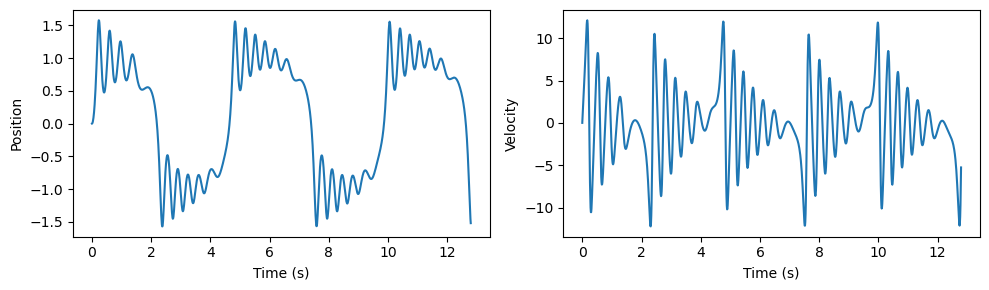

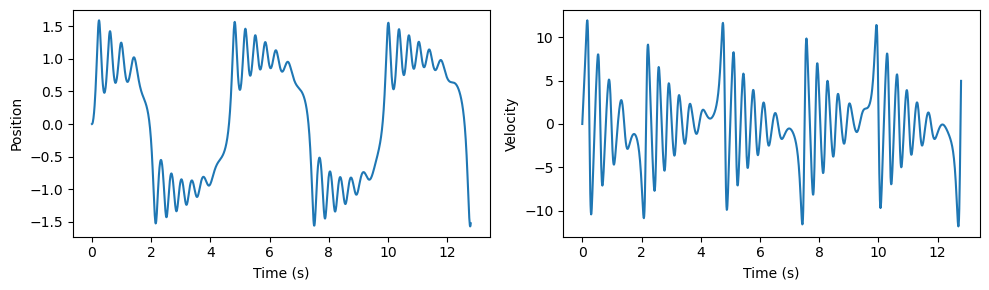

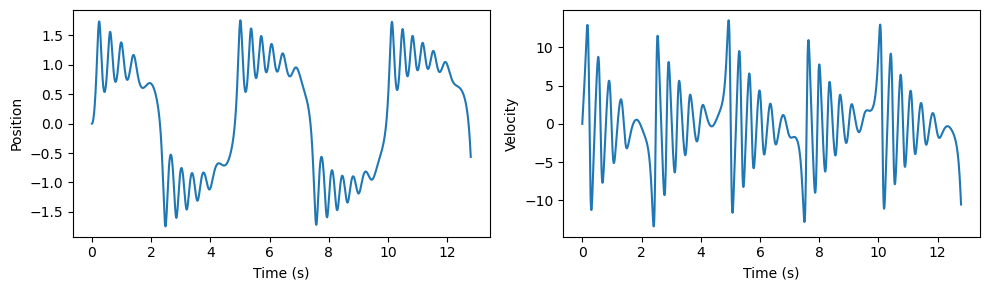

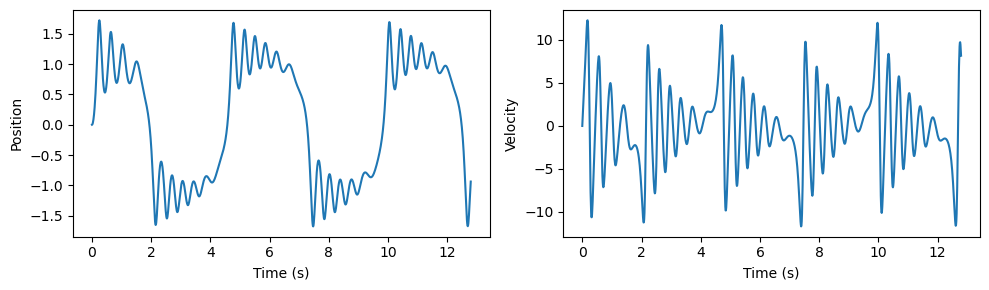

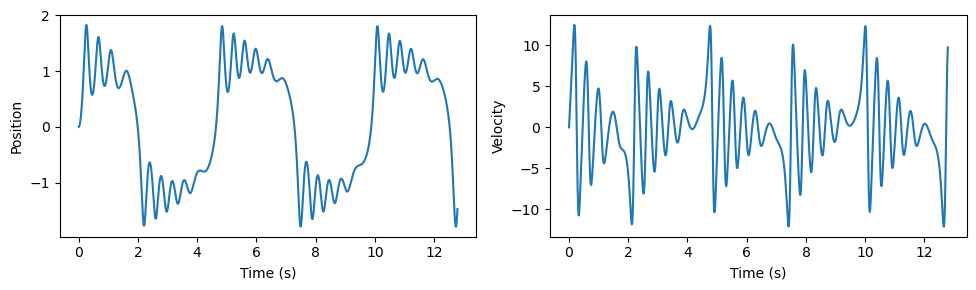

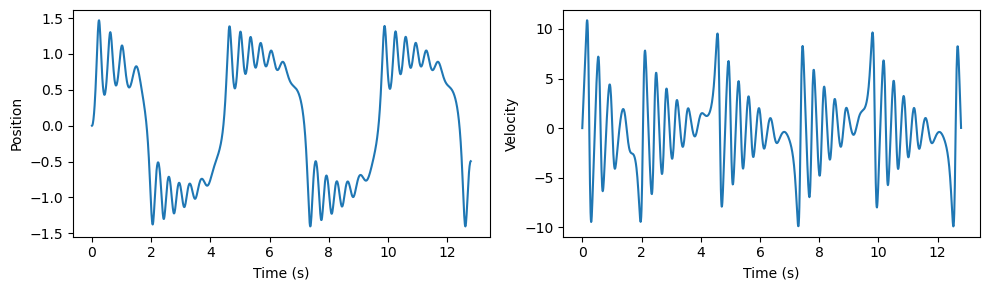

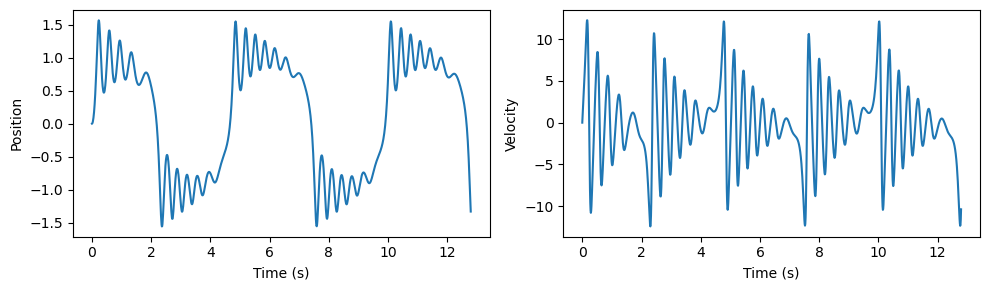

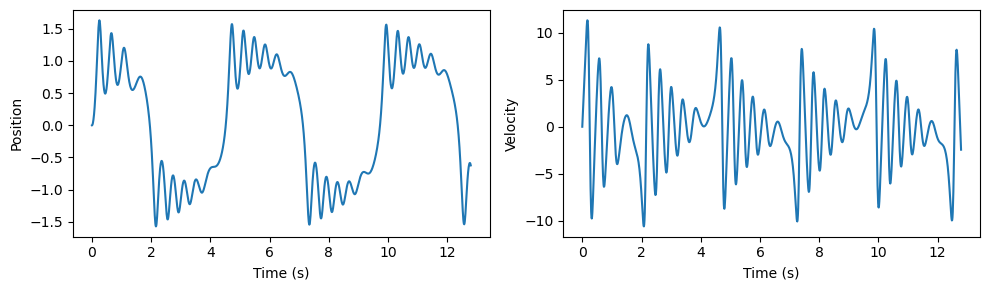

In [7]:
# --! plot results --!

for s in ss:
    plot_result(s, sim_nsample, dt)

### Process data into windows

In [8]:
def extract_windows(data, back_nsample, fore_nsample):

    windows = []

    data_nsample = data.shape[1]
    for d in data:
        for i in range(data_nsample):
            window_start = i - back_nsample
            window_end = i + fore_nsample
            if window_start >= 0 and window_end <= data_nsample:
                window = d[window_start:window_end, :]
                windows.append(window)

    return np.stack(windows)

data = ss
print(f'inf > simulated trajectories shape is {data.shape}')

fore_nsample = back_nsample // 2
windows = extract_windows(data, back_nsample, fore_nsample)
print(f'inf > extracted windows shape is {windows.shape}')

inf > simulated trajectories shape is (8, 1280, 2)
inf > extracted windows shape is (9480, 96, 2)


### Save data

In [9]:
datasaved = True

if datasaved:
    util_data.write_datafile(f'{data_dir}/windows', windows)
    print(f'inf > extracted windows saved')
    util_data.write_datafile(f'{data_dir}/trajectories', ss)
    print(f'inf > extracted trajectories saved')

inf > extracted windows saved
inf > extracted trajectories saved
